# odor_space_sampling functionality
This is a notebook that explores some of the functionality of this repo. Each section (vaugely) explores the different functions in the scripts of src/odor_space_sampling.

## `data.py`
This script is predominantly used for loading and working with raw csv files and coverting them into useable odor spaces. For example, it has functions for loading a csv.

In [1]:
from odor_space_sampling import data

path_to_data = "../data/gslf_and_human_data.csv"

df = data.load_csv(path_to_data)
print(df.head())

                smiles     label    cid                    IUPAC
0      Cc1ccnc2ccccc12  ['gslf']  10285        4-methylquinoline
1  CC(C)c1ccnc2ccccc12  ['gslf']  74004     4-isopropylquinoline
2      Cc1cnc2ccccc2n1  ['gslf']  23686      2-methylquinoxaline
3     Cc1nc2ccccc2nc1C  ['gslf']  16925  2,3-dimethylquinoxaline
4      Cc1cccc2nccnc12  ['gslf']  61670      5-methylquinoxaline


And there is a function to convert any csv into rdkit descriptors (as long as the csv has a "smiles" column with smiles strings)

In [2]:
data_matrix = data.make_rdkit_descriptors(path_to_data)
print(f"outputs a {data_matrix.shape} matrix corresponding to {data_matrix.shape[0]} odors by {data_matrix.shape[1]} descriptors")

generating descriptors: 100%|██████████| 5841/5841 [00:16<00:00, 353.26it/s]


outputs a (5841, 217) matrix corresponding to 5841 odors by 217 descriptors


In [3]:
print(data_matrix)

[[ 4.24203704  4.24203704  1.07638889 ...  0.          0.
   0.        ]
 [ 4.32425926  4.32425926  0.56287037 ...  0.          0.
   0.        ]
 [ 4.31314815  4.31314815  0.95657407 ...  0.          0.
   0.        ]
 ...
 [12.3299194  12.3299194   0.58849271 ...  0.          0.
   0.        ]
 [14.83846027 14.83846027  0.02170942 ...  0.          0.
   0.        ]
 [14.35132867 14.35132867  0.         ...  0.          0.
   0.        ]]


Which then you can reduce using PCA which gives you the features of the dataset that we have been using to sample

In [4]:
from odor_space_sampling import utils

reduced_data_matrix = utils.reduce_data(data_matrix)

initial data shape: (5841, 217)
dimension after removing constant features: (5841, 193)
dimensionality of 99% explained variance: 107
reduced space shape (5841, 107)


In practice, you can skip the individual steps above and use `data.load_and_prepare`, which loads both the data_matrix (after removing nan's, zscoring features, and doing PCA and keeping 99% explained variance) and the pandas df and returns an `OdorData` object that bundles the both together.

In [5]:
odor_data = data.load_and_prepare(path_to_data)
# odor_data.df  → the original dataframe (smiles, label, cid, IUPAC, ...)
# odor_data.x   → the processed data matrix, row i corresponds to odor_data.df.iloc[i]
print(odor_data.df.shape, odor_data.x.shape)

generating descriptors:   0%|          | 0/5841 [00:00<?, ?it/s]

generating descriptors: 100%|██████████| 5841/5841 [00:16<00:00, 359.44it/s]

initial data shape: (5841, 205)
dimension after removing constant features: (5841, 193)
dimensionality of 99% explained variance: 107
reduced space shape (5841, 107)
(5841, 4) (5841, 107)


Additionally this script can add CID and IUPAC names to the smiles strings in your csv by querying the pubchem api.

In [6]:
# create a csv without any CID or IUPCA names
no_cid_df = df.drop(columns=['cid', 'IUPAC']).iloc[:10]
no_cid_df.to_csv("../data/no_cid_test.csv", index=False) # saving it to a csv
print(no_cid_df)

                   smiles      label
0         Cc1ccnc2ccccc12   ['gslf']
1     CC(C)c1ccnc2ccccc12   ['gslf']
2         Cc1cnc2ccccc2n1   ['gslf']
3        Cc1nc2ccccc2nc1C   ['gslf']
4         Cc1cccc2nccnc12   ['gslf']
5     Cc1nc2ccccc2c(C)c1C  ['human']
6    CC(C)Cc1ccnc2ccccc12   ['gslf']
7  CC(C)(C)c1cccc2ncccc12   ['gslf']
8         Cc1ccc2ccccc2n1   ['gslf']
9         Cc1cccc2ccccc12   ['gslf']


In [7]:
# generate CID and IUPAC names back
cid_df = data.add_cid_to_data(filepath="../data/no_cid_test.csv", save=False)
print("newly generated CIDs and IUPAC names")
print(cid_df)
print("=====")
print("original dataframe")
print(df.iloc[:10])

generating CIDs: 10it [00:03,  2.67it/s]

newly generated CIDs and IUPAC names
                   smiles      label      cid                     IUPAC
0         Cc1ccnc2ccccc12   ['gslf']    10285         4-methylquinoline
1     CC(C)c1ccnc2ccccc12   ['gslf']    74004      4-isopropylquinoline
2         Cc1cnc2ccccc2n1   ['gslf']    23686       2-methylquinoxaline
3        Cc1nc2ccccc2nc1C   ['gslf']    16925   2,3-dimethylquinoxaline
4         Cc1cccc2nccnc12   ['gslf']    61670       5-methylquinoxaline
5     Cc1nc2ccccc2c(C)c1C  ['human']    17096  2,3,4-trimethylquinoline
6    CC(C)Cc1ccnc2ccccc12   ['gslf']    74005       4-isobutylquinoline
7  CC(C)(C)c1cccc2ncccc12   ['gslf']  unknown                   unknown
8         Cc1ccc2ccccc2n1   ['gslf']     7060         2-methylquinoline
9         Cc1cccc2ccccc12   ['gslf']     7002       1-methylnaphthalene
=====
original dataframe
                   smiles      label     cid                     IUPAC
0         Cc1ccnc2ccccc12   ['gslf']   10285         4-methylquinoline
1   

## `sampling.py`
This script has all of the sampling functions to sample odors in different ways. The easiest way to do all the sampling is to run the function `sample_with_all_methods`.

In [8]:
from odor_space_sampling import sampling

all_samples = sampling.sample_with_all_methods(odor_data, n_samples=100, seed=12345, n_gaussians=100)
print(all_samples)

{'uniform': {'samples': array([[ -1.16453369,  -7.86071031,  -4.08316609, ...,  -0.65923517,
          1.19426491,   0.32262318],
       [  7.12686789, -10.49183411,  -0.59531238, ...,  -0.28603634,
         -0.56026254,   0.44202601],
       [ 48.42518195, -22.04218417, -23.77979619, ...,  -1.76265909,
         -1.78919027,  -1.24798946],
       ...,
       [ 17.26130461,  15.8991092 ,  -4.54826792, ...,   0.1416046 ,
          0.09845184,   0.05034499],
       [  5.12461287, -11.23569002,  -6.0246075 , ...,   0.23199896,
         -0.44625777,   0.14933913],
       [ -5.52307724,  -5.16903051,  -2.54222852, ...,   0.52002379,
          1.25399945,  -0.90955475]], shape=(100, 107)), 'indices': array([4837, 5529, 5833, 3081, 5839, 5840, 5833, 5783, 5839, 5800, 5782,
       5783, 5839, 5833, 5839, 5813, 3081, 5826, 5831, 5839, 4383, 5065,
       5813, 3100, 5840, 5828, 5822, 5604, 4619, 5604, 5836, 5839, 5833,
       5831, 5839, 5833, 5813, 5826, 5839, 1296, 5833, 5833, 5532, 5428,
     

The output of `sample_with_all_methods` is a nested dictionary with one entry per sampling method:

```python
{
    "sampling_method_1": {
        "samples":   np.ndarray,  # the actual sampled points
        "indices":   np.ndarray,  # indices into the original odor dataset
        "distances": np.ndarray,  # distance from each sample to nearest real odor
    },
    "sampling_method_2": { ... },
    ...
}
```

> **Note:** `"distances"` is only included for methods that don't sample directly from the odor set (e.g. GMM), where sampled points may not correspond to real odors.

`sampling.py` also has functions that can generate different versions of gmm sampling (e.g. sample a gmm and get the n closest odorants, or create 20 different gmms and sample from them)

In [9]:
n_closest_points = 20
n_samples = 100
n_clusters = 120
sampling.get_n_closest_points_gmm(
    odor_data,
    n_closest_points,
    n_samples=n_samples,
    n_clusters=n_clusters,
    save_path=f"../data/gmm_sample_{n_closest_points}_points_{n_clusters}_gaussians_{n_samples}_samples.csv"
)

,sample,smiles,label,cid,IUPAC
0,0,CCCCCCCCCCCCCCCC(C)=O,['gslf'],18027,heptadecan-2-one
1,0,CCCCC=CCCCCCCCCCCCC=O,['gslf'],94120,octadec-13-enal
2,0,CCCCCCCCC=CCCCCCCCC=O,['gslf'],17029,octadec-9-enal
3,0,CCCCCCCCCCCCCCC(C)=O,"['human', 'gslf']",29251,hexadecan-2-one
4,0,CCCCCCCCCCCCCCCC=CC=O,['gslf'],41923,octadec-2-enal
...,...,...,...,...,...
1995,99,CCCCCCC1CCOC1=O,['gslf'],86736,3-hexyltetrahydrofuran-2-one
1996,99,CC(C)=CCCC1(C)CCC(=O)O1,['gslf'],9942315,5-methyl-5-(4-methylpent-3-enyl)tetrahydrofura...
1997,99,CCCCCC=CCC1CCC(=O)O1,['gslf'],62727,5-oct-2-enyltetrahydrofuran-2-one
1998,99,CCCCCCCC1CCC(=O)O1,"['human', 'gslf']",7714,5-heptyltetrahydrofuran-2-one


In [10]:
import numpy as np

sampling.gmm_resample_varying_seeds(
    odor_data,
    seeds=np.arange(5),
    save_path='../data/multiseed/gmm_multiseed'
)

iterating through seeds: 100%|██████████| 5/5 [00:35<00:00,  7.14s/it]


## analysis.py
This script is for functions that analyze sampling methods. For example you can run your own sweep of gaussian mixture models and find the minimum AIC and BIC values.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
fitting gmms: 100%|██████████| 10/10 [00:07<00:00,  1.31it/s]


<Figure size 640x480 with 0 Axes>

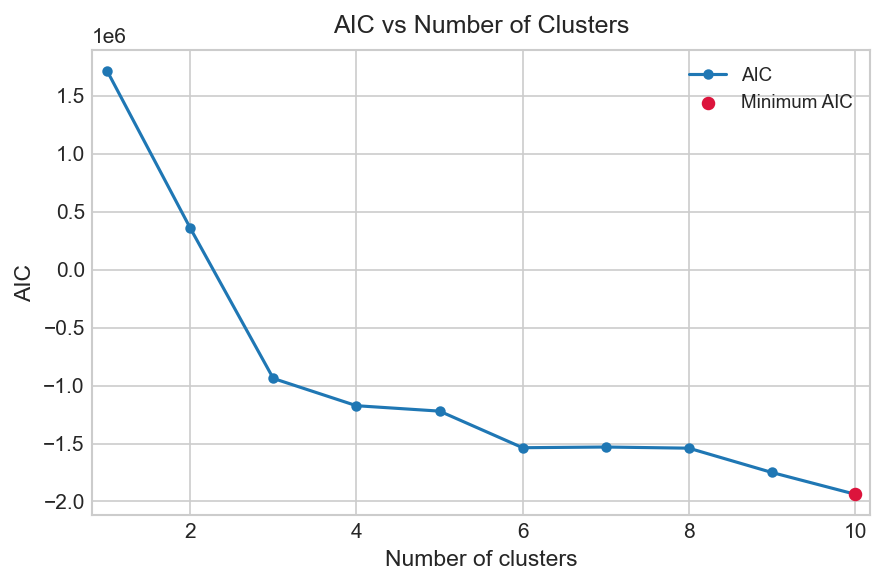

<Figure size 640x480 with 0 Axes>

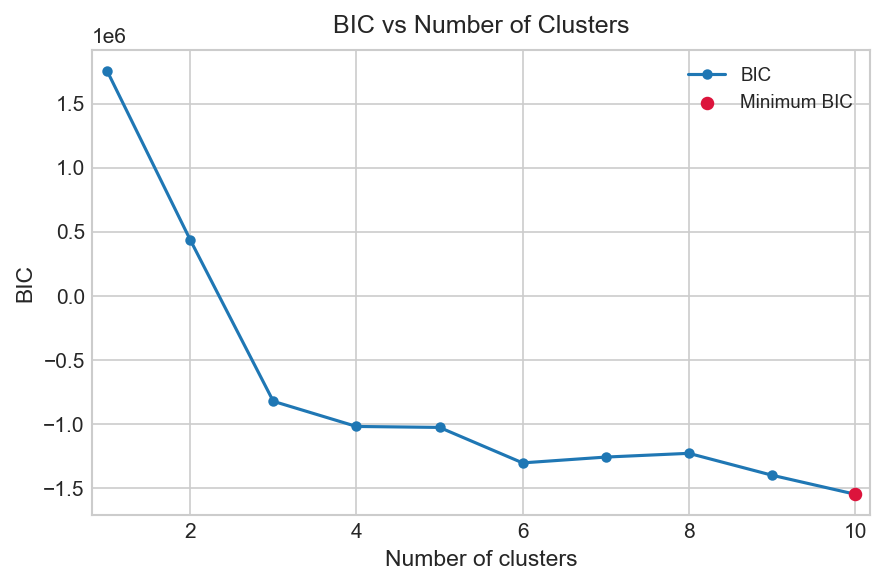

<Figure size 640x480 with 0 Axes>

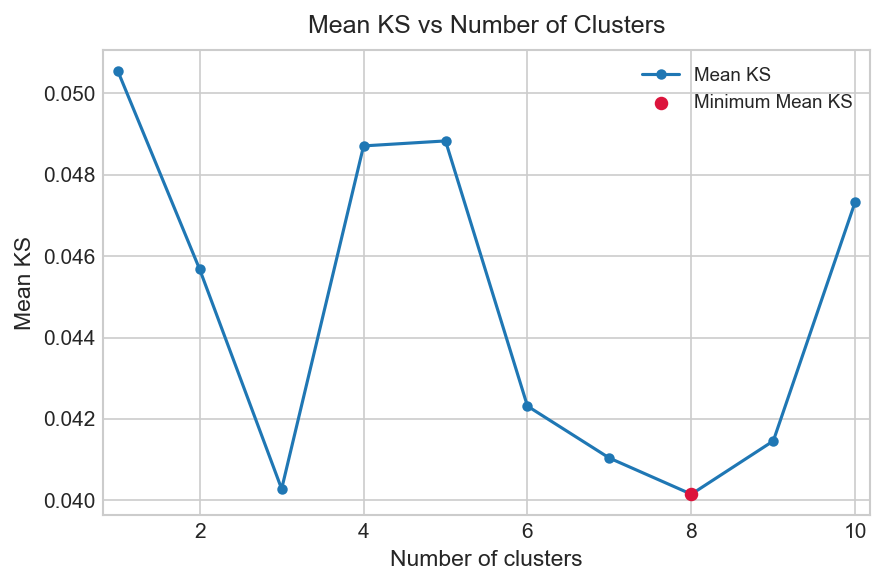

<Figure size 640x480 with 0 Axes>

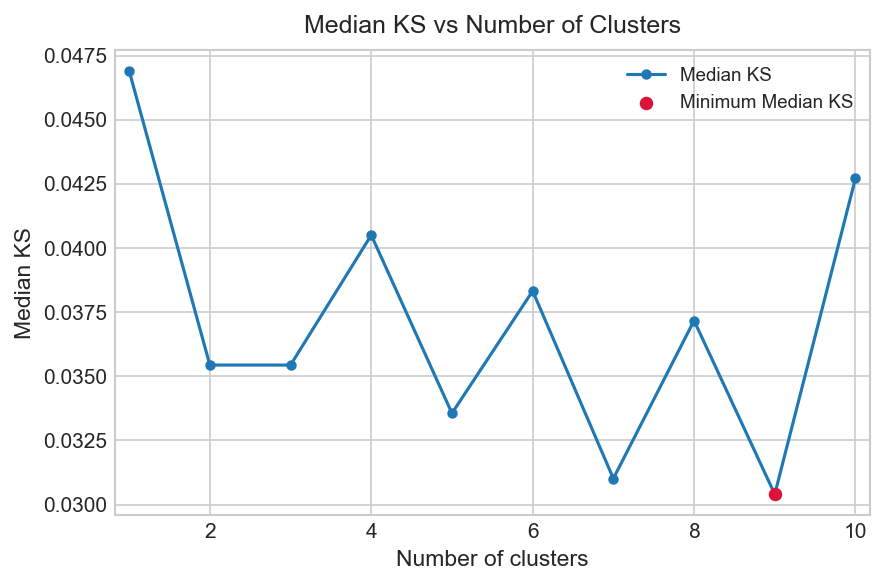

In [11]:
import numpy as np
from odor_space_sampling import analysis

aics, bics, ks_means, ks_meds = analysis.aic_and_bic_gmm(odor_data, max_n_clusters=10, plot=True) # only using 10 clusters because it takes a while with 200

In [12]:
print(f'best AIC: {np.argmin(aics) + 1} clusters')
print(f'best ks median: {np.argmin(ks_meds) + 1} clusters')
print(f'best ks mean: {np.argmin(ks_means) + 1} clusters')
print(f'best BIC: {np.argmin(bics) + 1} clusters')

best AIC: 10 clusters
best ks median: 9 clusters
best ks mean: 8 clusters
best BIC: 10 clusters


## plotting.py
This script is for functions that are used in plotting. Most of these functions can be used to generate plots of the statistics of odor space that we have been looking at. There are also some functions that help visualize the data as well.

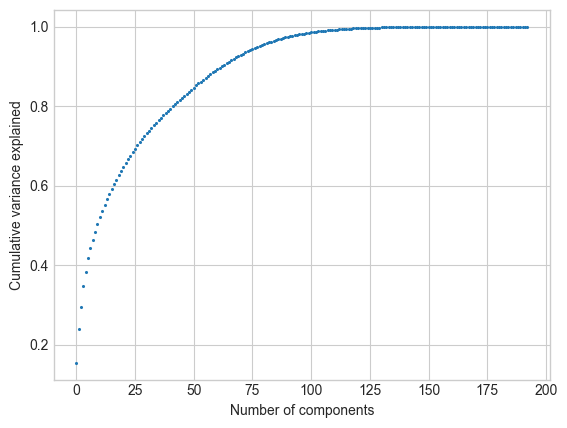

In [13]:
from odor_space_sampling import plotting
x = utils.remove_nans(data_matrix)
x = utils.remove_zero_var_descriptors(x)
x = utils.zscore_features(x)
plotting.plot_scree_plot(x)

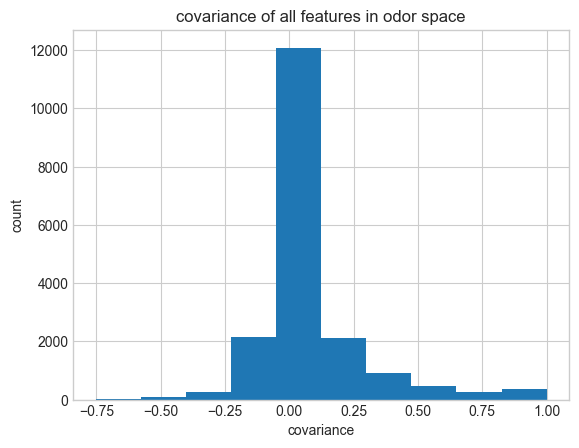

In [14]:
plotting.plot_feature_covariance(x)

There are also two functions for visualizing how each sampling method covers the odor space in PCA and UMAP 2D projections.

`plot_all_sampling_methods` takes the dict output of `sample_with_all_methods` directly and plots every method. You can also pass in extra `(indices, label)` pairs (e.g. from an external table) via `extra_methods`.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


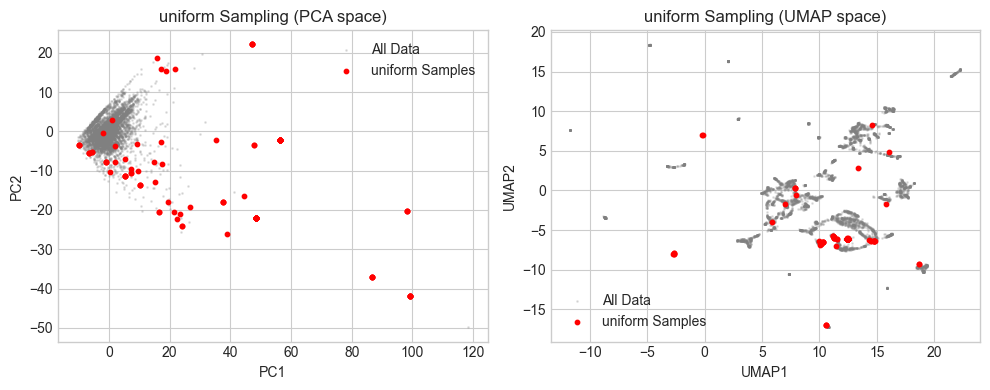

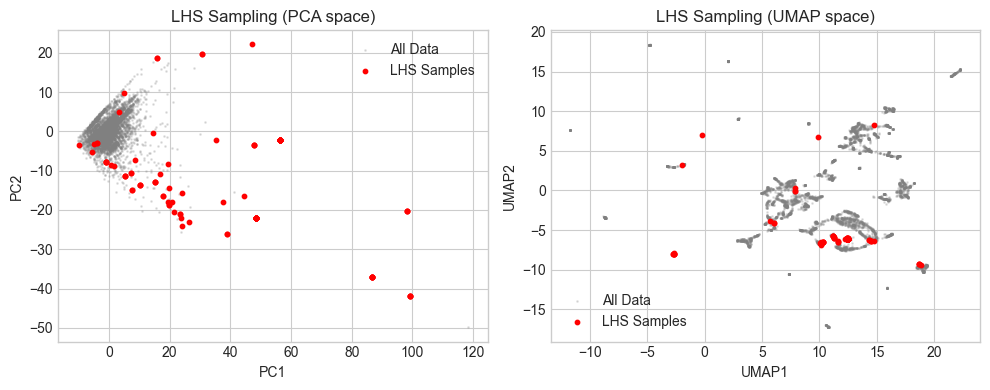

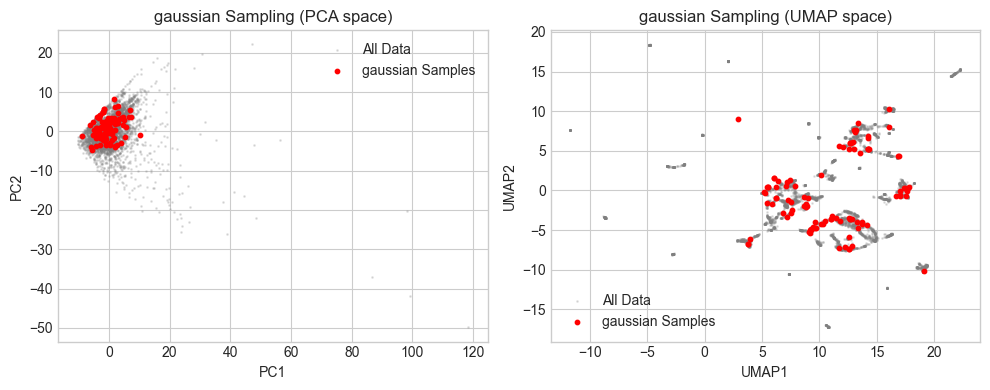

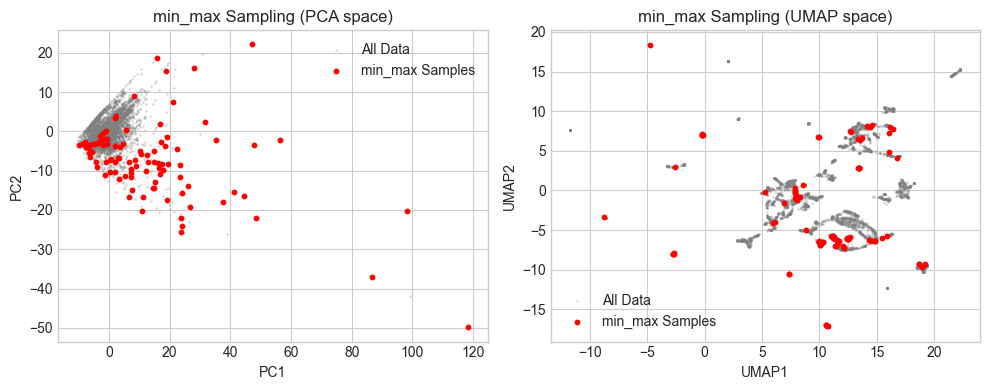

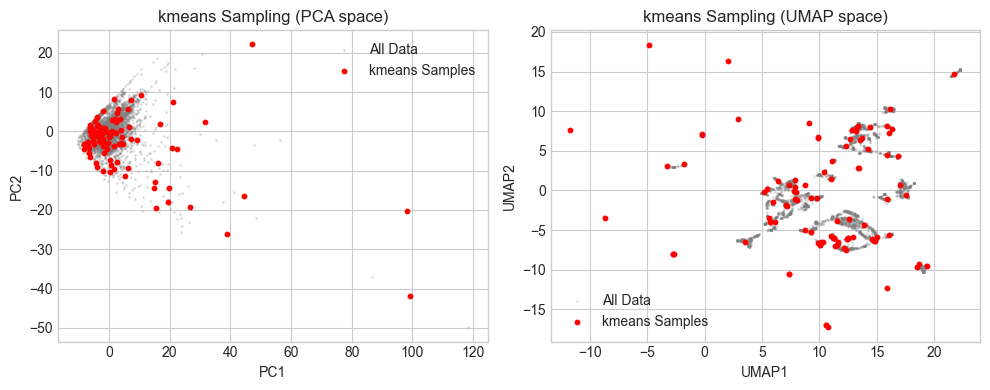

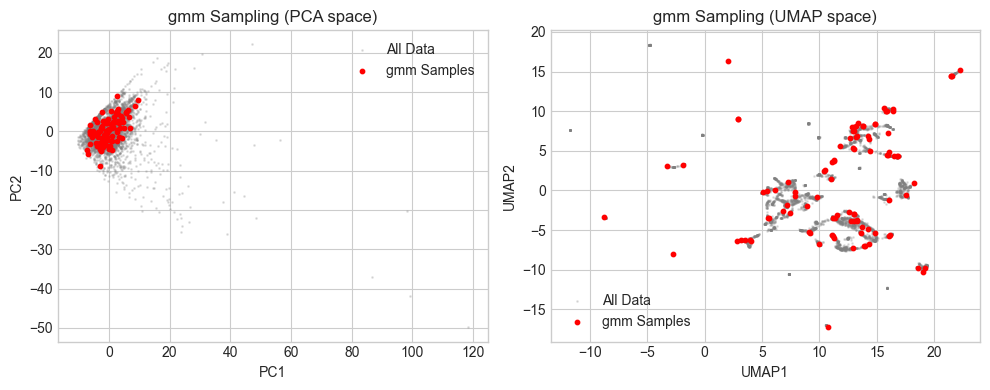

In [15]:
plotting.plot_all_sampling_methods(odor_data.x, all_samples)

If you want to plot a custom set of indices (e.g. from an external table alongside the sampled methods), use `plot_sampling_projections` directly with a list of `(indices, label)` pairs.

/Users/grantmcconachie/Desktop/research/TORI_PROJECTS/odor_space_sampling/venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


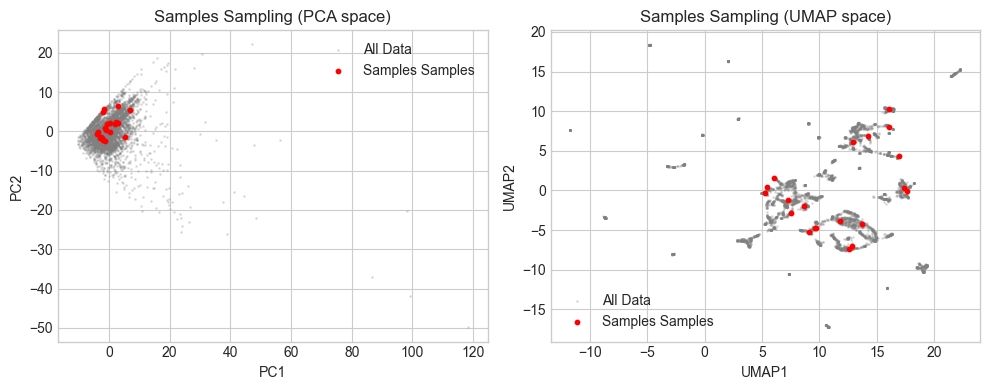

In [16]:
one_sample = sampling.gaussian_sample(odor_data.x, n_samples=20, seed=12345)
plotting.plot_sampling_projections(odor_data.x, one_sample)